# Workshop 4: EDA Pipeline (Titanic)

Notebook นี้สำหรับฝึก Exploratory Data Analysis (EDA) จาก Titanic dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toche7/SlideAIDATADGA/blob/main/slides/workshop-04-eda-pipeline.ipynb)

## Learning Objectives
- โหลดข้อมูลที่ผ่าน Data Preparation แล้ว
- สำรวจโครงสร้างข้อมูลและสถิติเบื้องต้น
- วิเคราะห์ความสัมพันธ์ที่เกี่ยวข้องกับการรอดชีวิต
- สรุป Insight ที่นำไปใช้ต่อในงานวิเคราะห์

In [1]:
# 1) Import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [2]:
# 2) Load cleaned Titanic data from Workshop 3 (fallback included)
clean_path = '/content/workshop3_titanic_clean.csv'
fallback_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

if os.path.exists(clean_path):
    df = pd.read_csv(clean_path)
    source_name = 'workshop3_titanic_clean.csv'
else:
    df = pd.read_csv(fallback_url)
    source_name = 'fallback Titanic CSV'

    # Minimal cleaning for standalone run
    if {'age', 'sex', 'Pclass'}.issubset(df.columns):
        df['age'] = df.groupby(['sex', 'Pclass'])['age'].transform(lambda s: s.fillna(s.median()))

    if 'Embarked' in df.columns:
        mode_embarked = df['Embarked'].mode(dropna=True)
        if not mode_embarked.empty:
            df['Embarked'] = df['Embarked'].fillna(mode_embarked.iloc[0])

    if 'Fare' in df.columns:
        df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce').fillna(df['Fare'].median())

print('Loaded from:', source_name)
print('Shape:', df.shape)
df.head()

Loaded from: workshop3_titanic_clean.csv
Shape: (784, 10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True


In [3]:
# 3) Standardize column names (support both seaborn and Kaggle-style schema)
rename_map = {
    'Survived': 'survived',
    'Pclass': 'pclass',
    'Sex': 'sex',
    'Age': 'age',
    'SibSp': 'sibsp',
    'Parch': 'parch',
    'Fare': 'fare',
    'Embarked': 'embarked',
    'PassengerId': 'passenger_id',
    'Name': 'name',
    'Ticket': 'ticket',
    'Cabin': 'cabin'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print('Columns:', list(df.columns))
df.head(3)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'adult_male', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True


In [4]:
# 4) Quick profile
display(df.info())
display(df.describe(include='all').T)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    784 non-null    int64  
 1   pclass      784 non-null    int64  
 2   sex         784 non-null    object 
 3   age         784 non-null    float64
 4   sibsp       784 non-null    int64  
 5   parch       784 non-null    int64  
 6   fare        784 non-null    float64
 7   embarked    784 non-null    object 
 8   adult_male  784 non-null    bool   
 9   alone       784 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(2)
memory usage: 50.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,784.0,NaN,NaN,NaN,0.41199,0.492507,0.0,0.0,0.0,1.0,1.0
pclass,784.0,NaN,NaN,NaN,2.243622,0.855056,1.0,1.0,3.0,3.0,3.0
sex,784,2,male,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,784.0,NaN,NaN,NaN,29.644668,13.951509,0.42,22.0,28.0,38.0,80.0
sibsp,784.0,NaN,NaN,NaN,0.522959,0.986231,0.0,0.0,0.0,1.0,8.0
parch,784.0,NaN,NaN,NaN,0.415816,0.836922,0.0,0.0,0.0,1.0,6.0
fare,784.0,NaN,NaN,NaN,34.71174,52.160151,0.0,8.05,15.9,34.10935,512.3292
embarked,784,3,S,570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_male,784,2,True,451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alone,784,2,True,446,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_pct
survived,0,0.0
pclass,0,0.0
sex,0,0.0
age,0,0.0
sibsp,0,0.0
parch,0,0.0
fare,0,0.0
embarked,0,0.0
adult_male,0,0.0
alone,0,0.0


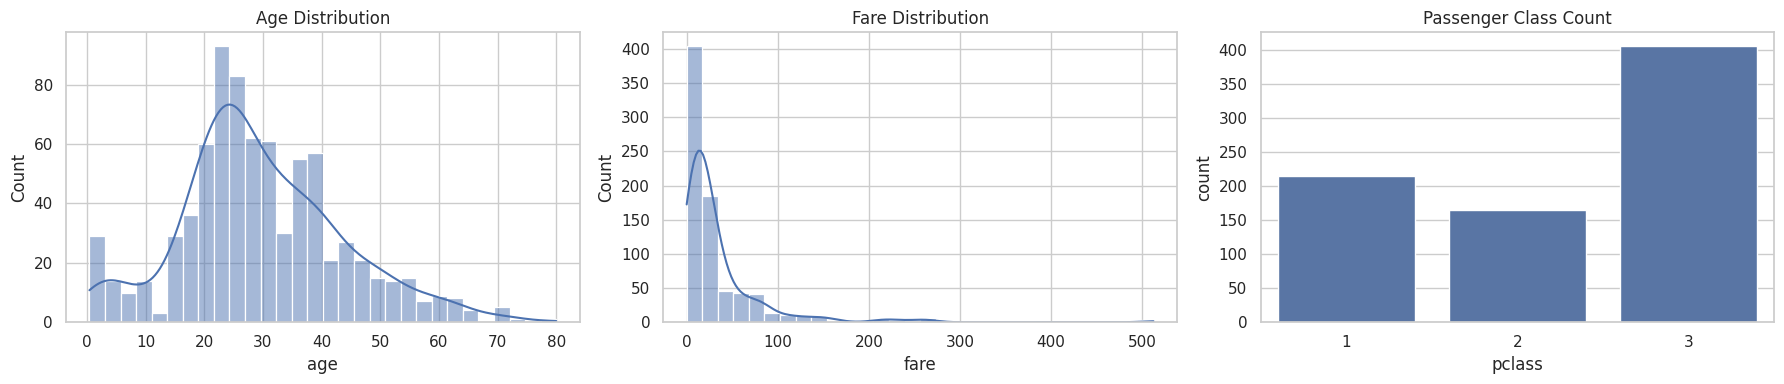

In [5]:
# 5) Univariate EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

if 'age' in df.columns:
    sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
    axes[0].set_title('Age Distribution')

if 'fare' in df.columns:
    sns.histplot(df['fare'], bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Fare Distribution')

if 'pclass' in df.columns:
    sns.countplot(data=df, x='pclass', ax=axes[2])
    axes[2].set_title('Passenger Class Count')

plt.tight_layout()
plt.show()

,sex,survived
0,female,0.740614
1,male,0.215886


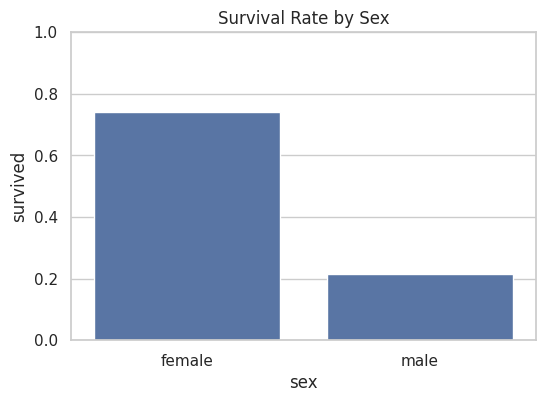

,pclass,survived
0,1,0.630841
1,2,0.509091
2,3,0.256790


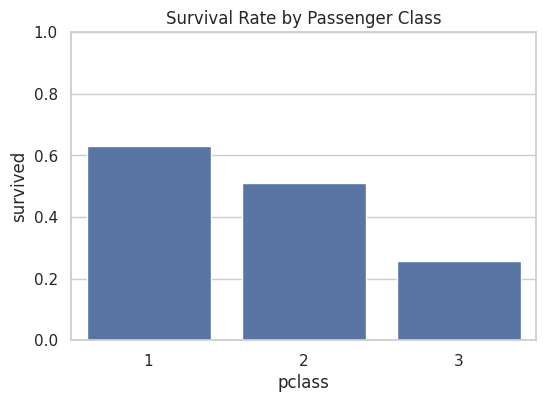

In [6]:
# 6) Bivariate EDA: survival by sex and class
if {'survived', 'sex'}.issubset(df.columns):
    surv_by_sex = df.groupby('sex', as_index=False)['survived'].mean().sort_values('survived', ascending=False)
    display(surv_by_sex)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=surv_by_sex, x='sex', y='survived')
    plt.title('Survival Rate by Sex')
    plt.ylim(0, 1)
    plt.show()

if {'survived', 'pclass'}.issubset(df.columns):
    surv_by_class = df.groupby('pclass', as_index=False)['survived'].mean().sort_values('pclass')
    display(surv_by_class)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=surv_by_class, x='pclass', y='survived')
    plt.title('Survival Rate by Passenger Class')
    plt.ylim(0, 1)
    plt.show()

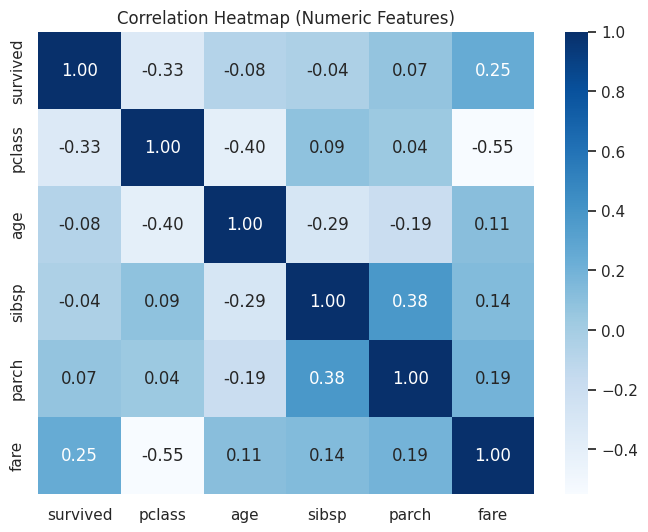

In [7]:
# 7) Correlation analysis (numeric columns)
num_df = df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [8]:
# 8) Tidy summary for reporting
summary = pd.DataFrame()

if {'survived', 'pclass', 'sex'}.issubset(df.columns):
    summary = (
        df.groupby(['pclass', 'sex'], as_index=False)
          .agg(
              passengers=('survived', 'size'),
              survival_rate=('survived', 'mean'),
              avg_age=('age', 'mean') if 'age' in df.columns else ('survived', 'size'),
              avg_fare=('fare', 'mean') if 'fare' in df.columns else ('survived', 'size')
          )
    )

if not summary.empty:
    summary['survival_rate'] = summary['survival_rate'].round(3)
    if 'avg_age' in summary.columns:
        summary['avg_age'] = summary['avg_age'].round(2)
    if 'avg_fare' in summary.columns:
        summary['avg_fare'] = summary['avg_fare'].round(2)

display(summary)

,pclass,sex,passengers,survival_rate,avg_age,avg_fare
0,1,female,93,0.968,34.76,106.52
1,1,male,121,0.372,41.07,67.55
2,2,female,73,0.918,28.42,22.19
3,2,male,92,0.185,31.06,21.55
4,3,female,127,0.472,21.97,15.70
5,3,male,278,0.158,26.32,12.72


In [9]:
# 9) Export outputs
df.to_csv('workshop4_titanic_eda_base.csv', index=False)
if 'summary' in globals() and len(summary) > 0:
    summary.to_csv('workshop4_titanic_eda_summary.csv', index=False)
    print('Saved: workshop4_titanic_eda_summary.csv')
print('Saved: workshop4_titanic_eda_base.csv')

Saved: workshop4_titanic_eda_summary.csv
Saved: workshop4_titanic_eda_base.csv


## Reflection Questions
1. ปัจจัยใดดูมีผลต่อการรอดชีวิตมากที่สุดระหว่าง sex, pclass, fare, age?
2. มีความเสี่ยงจากข้อมูลไม่สมบูรณ์หรือความเอนเอียงอะไรบ้าง?
3. ถ้าต้องวิเคราะห์ต่อเชิงนโยบาย ควรเพิ่มข้อมูลอะไรอีก?
4. เขียน Insight 3 ข้อในรูปแบบ bullet สำหรับนำเสนอผู้บริหาร